# User features

In [2]:
import pandas as pd
import seaborn as sns

## Users

In [3]:
df_users = pd.read_csv("data/data_preprocessed/users_preprocessed.csv")

In [4]:
df_users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,sign_up_year
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54,2022
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53,2022
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,46,2022
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47,2022
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52,2023
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47,2023
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48,2023
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47,2023


### Amont of sessions

In [5]:
sessions = pd.read_csv("data/data_preprocessed/sessions_preprocessed.csv")

In [6]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,474007-3f94a8eeac6441768dbcc9e138150ad1,474007,NaN,2023-02-14 12:12:00,2023-02-14 12:12:30,False,False,NaN,NaN,False,False,4,False
1,476124-0a2b1fe2cd8445749421d95afc686201,476124,NaN,2023-02-14 21:47:00,2023-02-14 21:47:45,False,False,NaN,NaN,False,False,6,False
2,486605-78e96c1b97af4a078d41bfa3697004ca,486605,NaN,2023-02-14 19:20:00,2023-02-14 19:20:39,False,True,NaN,0.20,False,False,5,False
3,486751-997cd295ede648dbabf6c45d54c9f2f5,486751,NaN,2023-02-14 13:22:00,2023-02-14 13:23:06,False,False,NaN,NaN,False,False,9,False
4,488099-18cbf909cfc246b3978c42042ea8bd14,488099,NaN,2023-02-14 22:26:00,2023-02-14 22:26:29,False,False,NaN,NaN,False,False,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,445351-53e733391f4f49b2b819b3c9fbdf639e,445351,445351-7946218c0beb4822afd82636ab495f4f,2023-02-14 14:16:00,2023-02-14 14:20:34,False,True,NaN,0.20,True,True,36,False
48679,445515-c77a953bee954480bfba1cd9e4548225,445515,NaN,2023-02-14 19:21:00,2023-02-14 19:23:24,False,False,NaN,NaN,False,False,20,False
48680,447053-0de75caa6dba4aa0b2066cc1bb5363e6,447053,NaN,2023-02-14 06:05:00,2023-02-14 06:05:59,False,False,NaN,NaN,False,False,8,False
48681,450305-7e1c13467e0b4f6996968a36250e7f93,450305,NaN,2023-02-14 02:20:00,2023-02-14 02:22:21,False,False,NaN,NaN,False,False,19,False


In [7]:
anzahl_sessions_feature = sessions.groupby("user_id")["session_id"].count().rename("num_session") # feature

### Anzahl Trip 

## total

In [8]:
sessions.groupby("user_id")["trip_id"].nunique()

user_id
94883     3
101486    4
101961    7
106907    3
118043    6
         ..
792549    4
796032    3
801660    3
811077    1
844489    0
Name: trip_id, Length: 5782, dtype: int64

In [9]:
sessions[sessions["cancellation"]] # dataset von allen trips die sotroniert worden sind

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
15891,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
15892,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
15893,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
15894,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
15895,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40742,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
40743,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
40744,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
40745,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


In [10]:
cancelled_trip_ids = sessions[sessions["cancellation"]]["trip_id"] # alle meine gencancellten trips

In [11]:
valid_sessions = sessions[~sessions["trip_id"].isin(cancelled_trip_ids)] # mit verneiung behalte ich alle trips die true sind 

In [12]:
valid_sessions.groupby("user_id")["trip_id"].nunique()

user_id
94883     3
101486    3
101961    7
106907    2
118043    5
         ..
792549    4
796032    2
801660    3
811077    1
844489    0
Name: trip_id, Length: 5782, dtype: int64

In [13]:
anzahl_trips_feature = valid_sessions.groupby("user_id")["trip_id"].nunique().rename("num_trips")

## Anzahl Hotels and flights

In [14]:
valid_sessions.columns

Index(['session_id', 'user_id', 'trip_id', 'session_start', 'session_end',
       'flight_discount', 'hotel_discount', 'flight_discount_amount',
       'hotel_discount_amount', 'flight_booked', 'hotel_booked', 'page_clicks',
       'cancellation'],
      dtype='str')

In [15]:
valid_sessions.groupby("user_id")["flight_booked"].count()

user_id
94883     12
101486    11
101961    12
106907    12
118043    11
          ..
792549     8
796032     6
801660     8
811077     8
844489     8
Name: flight_booked, Length: 5782, dtype: int64

In [16]:
anzahl_flights_feature = valid_sessions.groupby("user_id")["flight_booked"].sum().rename("num_flights") # Feature

In [17]:
anzahl_hotels_feature = valid_sessions.groupby("user_id")["hotel_booked"].sum().rename("num_hotels") # Feature

In [18]:
valid_sessions.shape

(47455, 13)

In [19]:
sessions.shape

(48683, 13)

## booking discount rate

In [20]:
valid_sessions[['flight_discount', 'hotel_discount']].value_counts()

flight_discount  hotel_discount
False            False             34509
True             False              6855
False            True               4871
True             True               1220
Name: count, dtype: int64

In [21]:
valid_sessions[~valid_sessions.trip_id.isna()][['flight_discount', 'hotel_discount']].value_counts() # leute die etwas gebuicht haben (die nicht-bucher sind gelöscht worden)

flight_discount  hotel_discount
False            False             11479
True             False              1917
False            True               1772
True             True                382
Name: count, dtype: int64

In [22]:
valid_sessions[~valid_sessions.trip_id.isna()][['user_id', 'flight_discount', 'hotel_discount']].groupby("user_id").value_counts()

user_id  flight_discount  hotel_discount
94883    False            False             3
101486   False            False             2
         True             False             1
101961   False            False             6
         True             False             1
                                           ..
792549   False            False             4
796032   False            False             2
801660   False            False             2
         True             False             1
811077   False            False             1
Name: count, Length: 8433, dtype: int64

In [23]:
valid_sessions[~valid_sessions.trip_id.isna()].groupby(['user_id', 'flight_discount', 'hotel_discount']).size().unstack(['flight_discount', 'hotel_discount'], fill_value=0)

flight_discount,False,True,False,True
hotel_discount,False,False,True,True
user_id,,,,
94883,3,0,0,0
101486,2,1,0,0
101961,6,1,0,0
106907,1,0,1,0
118043,2,0,2,1
...,...,...,...,...
785186,2,0,0,0
792549,4,0,0,0


In [24]:
user_discount_type = valid_sessions[~valid_sessions.trip_id.isna()].groupby(['user_id', 'flight_discount', 'hotel_discount']).size().unstack(['flight_discount', 'hotel_discount'], fill_value=0)

In [25]:
user_discount_type

flight_discount,False,True,False,True
hotel_discount,False,False,True,True
user_id,,,,
94883,3,0,0,0
101486,2,1,0,0
101961,6,1,0,0
106907,1,0,1,0
118043,2,0,2,1
...,...,...,...,...
785186,2,0,0,0
792549,4,0,0,0


In [26]:
user_discount_type[[(False, True), (True, False), (True, True)]].sum(axis=1) # wieviele trips mit rabatt haben die User gekauft

user_id
94883     0
101486    1
101961    1
106907    1
118043    3
         ..
785186    0
792549    0
796032    0
801660    1
811077    0
Length: 5274, dtype: int64

In [27]:
user_discount_type.sum(axis=1) # wieviele trips insgesamt die user gemacht haben

user_id
94883     3
101486    3
101961    7
106907    2
118043    5
         ..
785186    2
792549    4
796032    2
801660    3
811077    1
Length: 5274, dtype: int64

In [28]:
user_discount_type[[(False, True), (True, False), (True, True)]].sum(axis=1) / user_discount_type.sum(axis=1) # wieviel % rabatt (egal ob flug oder hotel) User bekommen hat

user_id
94883     0.000000
101486    0.333333
101961    0.142857
106907    0.500000
118043    0.600000
            ...   
785186    0.000000
792549    0.000000
796032    0.000000
801660    0.333333
811077    0.000000
Length: 5274, dtype: float64

In [29]:
booking_discount_rate_feature = user_discount_type[[(False, True), (True, False), (True, True)]].sum(axis=1) / user_discount_type.sum(axis=1).rename("booking_discount_rate") # Feature

In [30]:
booking_discount_rate_feature = booking_discount_rate_feature.rename("booking_discount_rate") # von allen trips die diese Person gehabt hat wieviel discounts hatte sie gehabt

# Average Seats

In [31]:
flights = pd.read_csv("data/raw_data/flights.csv")

In [32]:
valid_flights = flights[~flights["trip_id"].isin(cancelled_trip_ids)]
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02
13763,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45
13764,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56
13765,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09


we have around 500 flights that are valid, this means there were flights in the fligts table that were cancelled.

In [33]:
user_trip_ids = sessions[["user_id", "trip_id"]]

In [34]:
user_trip_ids

,user_id,trip_id
0,474007,NaN
1,476124,NaN
2,486605,NaN
3,486751,NaN
4,488099,NaN
...,...,...
48678,445351,445351-7946218c0beb4822afd82636ab495f4f
48679,445515,NaN
48680,447053,NaN
48681,450305,NaN


In [35]:
valid_flights = valid_flights.merge(user_trip_ids, on="trip_id")

In [36]:
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090


In [37]:
average_seats_feature = valid_flights.groupby("user_id")["seats"].mean().rename("average_seats") # feature

In [38]:
average_seats_feature

user_id
94883     1.666667
101486    1.000000
101961    1.000000
106907    1.000000
118043    2.000000
            ...   
785186    1.000000
792549    1.000000
796032    1.000000
801660    1.000000
811077    1.000000
Name: average_seats, Length: 4891, dtype: float64

In [39]:
valid_flights["seats"].mean()

np.float64(1.1833055597636721)

<Axes: xlabel='seats', ylabel='count'>

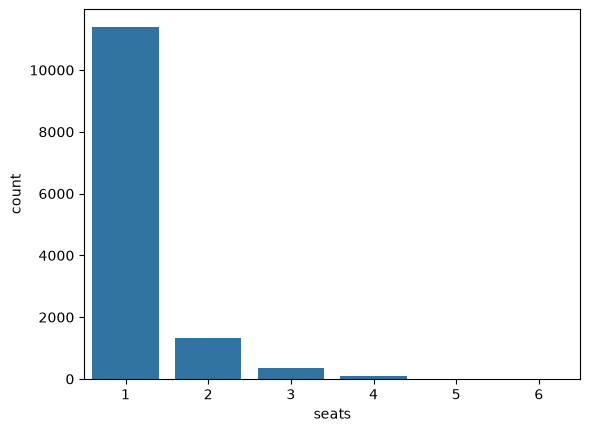

In [40]:
sns.countplot(data= valid_flights, x=  "seats")

In [41]:
valid_flights["seats"].value_counts()

seats
1    11395
2     1331
3      356
4      108
5        7
6        5
Name: count, dtype: int64

In [42]:
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090


In [43]:
pd.DataFrame(average_seats_feature).value_counts()

average_seats
1.000000         3337
1.500000          334
1.333333          279
2.000000          264
1.250000          219
1.666667          114
1.200000           86
1.400000           51
1.750000           40
1.166667           38
3.000000           32
2.500000           27
1.600000           16
1.800000            9
1.142857            6
4.000000            6
2.333333            5
1.428571            4
1.285714            4
2.250000            4
3.500000            3
1.375000            2
1.571429            2
2.666667            2
1.125000            1
1.777778            1
1.857143            1
6.000000            1
1.833333            1
2.200000            1
5.000000            1
Name: count, dtype: int64

# User State

In [44]:
from airports import Airports

#initialize the library
airports = Airports()

#look up an airport by its IATA code
lax_info = airports.find_by_iata_code("MCI")

if lax_info:
    # the 'region' key contains the state name
    state = lax_info.get('region')
    print(f"LAX is in: {state}")
    # output: LAX is in: california

LAX is in: Missouri


In [45]:
airports = Airports()

def iata_to_state(iata):
    #initialize the library
    

    #look up an airport by its IATA code
    lax_info = airports.find_by_iata_code(iata)

    if lax_info:
        # the 'region' key contains the state name
        return lax_info.get('region')

In [46]:
df_users["home_airport"].apply(iata_to_state)

0            Missouri
1          Washington
2       Massachusetts
3             Florida
4          California
            ...      
5777       California
5778         Arkansas
5779         Missouri
5780        Tennessee
5781            Texas
Name: home_airport, Length: 5782, dtype: str

In [47]:
df_users["states"] = df_users["home_airport"].apply(iata_to_state)

In [48]:
df_users["states"].value_counts()

states
California                  885
Texas                       705
New York                    698
Ontario                     336
Quebec                      215
Illinois                    194
Florida                     181
Arizona                     158
Tennessee                   144
Ohio                        130
Alberta                     124
Virginia                    119
Oklahoma                     96
Missouri                     92
Pennsylvania                 87
Colorado                     85
North Carolina               84
Wisconsin                    83
British Columbia             79
Louisiana                    78
Washington                   77
Nevada                       74
Alabama                      72
Gujarat                      71
Michigan                     63
Kentucky                     58
Nebraska                     53
Massachusetts                52
Iowa                         48
Maryland                     46
Arkansas                     41
M

In [49]:
valid_flights.merge(df_users[["user_id","states"]], on="user_id")

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,states
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884,Arkansas
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607,Florida
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445,Florida
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623,Quebec
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043,Texas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677,Tennessee
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223,Tennessee
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956,Ontario
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090,Arizona


In [50]:
valid_flights = valid_flights.merge(df_users[["user_id","states"]], on="user_id")

In [51]:
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,states
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884,Arkansas
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607,Florida
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445,Florida
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623,Quebec
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043,Texas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677,Tennessee
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223,Tennessee
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956,Ontario
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090,Arizona


In [52]:
valid_flights.groupby("states")["trip_id"].count()

states
Alabama                      125
Alaska                        46
Alberta                      261
Arizona                      385
Arkansas                      86
British Columbia             168
California                  1921
Colorado                     187
Florida                      350
Georgia                       74
Gujarat                      204
Hawaii                        69
Ica                           38
Illinois                     480
Iowa                          86
Kansas                        63
Kentucky                     142
Louisiana                    127
Maine                         44
Manitoba                      88
Maryland                     122
Massachusetts                114
Michigan                     153
Minnesota                     58
Missouri                     186
Nebraska                     112
Nevada                       199
New Jersey                    46
New York                    1694
North Carolina               184
Nov

In [53]:
valid_flights["price_per_seat"] = valid_flights["base_fare_usd"]/valid_flights["seats"]

In [54]:
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,states,price_per_seat
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884,Arkansas,492.466667
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607,Florida,326.820000
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445,Florida,371.830000
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623,Quebec,97.890000
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043,Texas,435.640000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677,Tennessee,246.673333
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223,Tennessee,576.450000
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956,Ontario,173.560000
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090,Arizona,507.090000


# Average seat price

In [55]:
valid_flights.groupby("user_id")["price_per_seat"].mean()

user_id
94883     932.630000
101486    180.130000
101961    321.533333
106907    165.510000
118043    445.847222
             ...    
785186    176.675000
792549    259.792500
796032    360.760000
801660    136.653333
811077    579.790000
Name: price_per_seat, Length: 4891, dtype: float64

In [56]:
average_seats_price_feature = valid_flights.groupby("user_id")["price_per_seat"].mean().rename("average_seats_price")

# checked bags

In [57]:
valid_flights.groupby("user_id")["checked_bags"].mean()

user_id
94883     1.000000
101486    0.500000
101961    0.500000
106907    1.000000
118043    1.000000
            ...   
785186    0.000000
792549    0.500000
796032    0.500000
801660    0.333333
811077    0.000000
Name: checked_bags, Length: 4891, dtype: float64

In [58]:
checked_bags_feature = valid_flights.groupby("user_id")["checked_bags"].mean().rename("average_checked_bags") # Feature

# weekend trip

In [59]:
hotels = pd.read_csv("data/data_preprocessed/hotels_preprocessed.csv")

In [60]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,hotel_city
0,574465-ff51972344c041fa97c9eb8bcc071cb4,Best Western,0,1,2023-04-22 15:30:48.96,2023-04-23 11:00:00,366,portland
1,596361-cf65c7c360a4431b9ca9605c74a94e73,InterContinental,11,1,2023-04-18 17:54:37.935,2023-04-30 11:00:00,179,dallas
2,540572-5a836a394a8a4cd7a1bba7f0e7eb0494,Four Seasons,3,1,2023-04-27 15:48:00.945,2023-05-01 11:00:00,148,edmonton
3,482264-e73c1866d23d4c9082893cfcaf77d13f,Radisson,8,1,2023-04-20 11:33:32.4,2023-04-28 11:00:00,208,new york
4,454934-2b0809d98c0a466ab8f1502d8c229ffc,Best Western,1,1,2023-04-24 17:56:46.095,2023-04-26 11:00:00,220,calgary
...,...,...,...,...,...,...,...,...
14369,532365-7d2445685a43412d997f5195603a7030,Aman Resorts,5,3,2023-04-16 10:09:15.525,2023-04-21 11:00:00,130,dallas
14370,516251-bcf75616755f4cd7ba29c15d5dd1caf6,Choice Hotels,0,1,2023-04-17 18:57:40.05,2023-04-18 11:00:00,140,washington
14371,517675-49cc5226a9db4f80845e2765563d99c5,Aman Resorts,3,1,2023-04-18 18:23:25.53,2023-04-22 11:00:00,122,los angeles
14372,521743-07935a4ea37b4fc0aee940d8cee5062b,Radisson,1,1,2023-04-17 13:39:11.205,2023-04-19 11:00:00,191,tucson


In [61]:
hotels.shape

(14374, 8)

In [62]:
valid_hotels = hotels[~hotels["trip_id"].isin(cancelled_trip_ids)]
valid_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,hotel_city
0,574465-ff51972344c041fa97c9eb8bcc071cb4,Best Western,0,1,2023-04-22 15:30:48.96,2023-04-23 11:00:00,366,portland
1,596361-cf65c7c360a4431b9ca9605c74a94e73,InterContinental,11,1,2023-04-18 17:54:37.935,2023-04-30 11:00:00,179,dallas
2,540572-5a836a394a8a4cd7a1bba7f0e7eb0494,Four Seasons,3,1,2023-04-27 15:48:00.945,2023-05-01 11:00:00,148,edmonton
3,482264-e73c1866d23d4c9082893cfcaf77d13f,Radisson,8,1,2023-04-20 11:33:32.4,2023-04-28 11:00:00,208,new york
5,523666-c0cea15438ee4d18b56215ad4a9b4409,Hilton,1,1,2023-04-23 19:32:52.08,2023-04-25 11:00:00,98,el paso
...,...,...,...,...,...,...,...,...
14369,532365-7d2445685a43412d997f5195603a7030,Aman Resorts,5,3,2023-04-16 10:09:15.525,2023-04-21 11:00:00,130,dallas
14370,516251-bcf75616755f4cd7ba29c15d5dd1caf6,Choice Hotels,0,1,2023-04-17 18:57:40.05,2023-04-18 11:00:00,140,washington
14371,517675-49cc5226a9db4f80845e2765563d99c5,Aman Resorts,3,1,2023-04-18 18:23:25.53,2023-04-22 11:00:00,122,los angeles
14372,521743-07935a4ea37b4fc0aee940d8cee5062b,Radisson,1,1,2023-04-17 13:39:11.205,2023-04-19 11:00:00,191,tucson


In [63]:
valid_hotels["check_in_time"] = pd.to_datetime(valid_hotels["check_in_time"], format="mixed")


In [64]:
valid_hotels["check_out_time"] = pd.to_datetime(valid_hotels["check_out_time"], format="mixed")

In [65]:
valid_hotels["check_in_time"].dt.weekday

0        5
1        1
2        3
3        3
5        6
        ..
14369    6
14370    0
14371    1
14372    0
14373    4
Name: check_in_time, Length: 13957, dtype: int32

In [66]:
valid_hotels["check_in_time"].dt.weekday.apply(lambda x: True if x in [5,6] else False)

0         True
1        False
2        False
3        False
5         True
         ...  
14369     True
14370    False
14371    False
14372    False
14373    False
Name: check_in_time, Length: 13957, dtype: bool

In [67]:
valid_hotels["check_in_time"].dt.weekday.value_counts()

check_in_time
4    2044
6    2021
3    1994
1    1993
5    1983
2    1980
0    1942
Name: count, dtype: int64

In [68]:
valid_hotels["is_weekend"] = valid_hotels["check_in_time"].dt.weekday.apply(lambda x: True if x in [5,6] else False)

In [69]:
valid_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,hotel_city,is_weekend
0,574465-ff51972344c041fa97c9eb8bcc071cb4,Best Western,0,1,2023-04-22 15:30:48.960,2023-04-23 11:00:00,366,portland,True
1,596361-cf65c7c360a4431b9ca9605c74a94e73,InterContinental,11,1,2023-04-18 17:54:37.935,2023-04-30 11:00:00,179,dallas,False
2,540572-5a836a394a8a4cd7a1bba7f0e7eb0494,Four Seasons,3,1,2023-04-27 15:48:00.945,2023-05-01 11:00:00,148,edmonton,False
3,482264-e73c1866d23d4c9082893cfcaf77d13f,Radisson,8,1,2023-04-20 11:33:32.400,2023-04-28 11:00:00,208,new york,False
5,523666-c0cea15438ee4d18b56215ad4a9b4409,Hilton,1,1,2023-04-23 19:32:52.080,2023-04-25 11:00:00,98,el paso,True
...,...,...,...,...,...,...,...,...,...
14369,532365-7d2445685a43412d997f5195603a7030,Aman Resorts,5,3,2023-04-16 10:09:15.525,2023-04-21 11:00:00,130,dallas,True
14370,516251-bcf75616755f4cd7ba29c15d5dd1caf6,Choice Hotels,0,1,2023-04-17 18:57:40.050,2023-04-18 11:00:00,140,washington,False
14371,517675-49cc5226a9db4f80845e2765563d99c5,Aman Resorts,3,1,2023-04-18 18:23:25.530,2023-04-22 11:00:00,122,los angeles,False
14372,521743-07935a4ea37b4fc0aee940d8cee5062b,Radisson,1,1,2023-04-17 13:39:11.205,2023-04-19 11:00:00,191,tucson,False


In [70]:
valid_hotels["is_weekend"].value_counts()

is_weekend
False    9953
True     4004
Name: count, dtype: int64

<Axes: xlabel='check_in_time'>

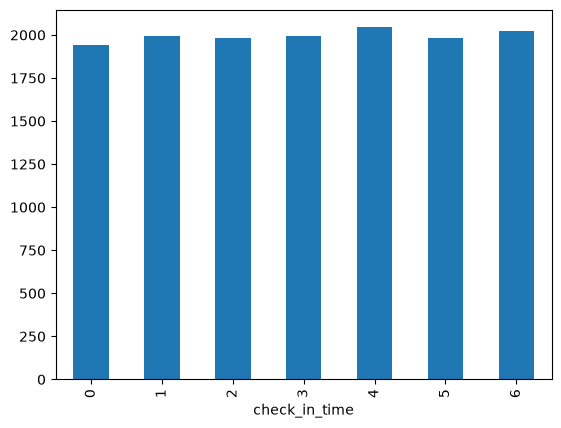

In [71]:
valid_hotels["check_in_time"].dt.weekday.value_counts().sort_index().plot(kind="bar")

In [72]:
valid_hotels= valid_hotels.merge(user_trip_ids, on="trip_id")

In [73]:
valid_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,hotel_city,is_weekend,user_id
0,574465-ff51972344c041fa97c9eb8bcc071cb4,Best Western,0,1,2023-04-22 15:30:48.960,2023-04-23 11:00:00,366,portland,True,574465
1,596361-cf65c7c360a4431b9ca9605c74a94e73,InterContinental,11,1,2023-04-18 17:54:37.935,2023-04-30 11:00:00,179,dallas,False,596361
2,540572-5a836a394a8a4cd7a1bba7f0e7eb0494,Four Seasons,3,1,2023-04-27 15:48:00.945,2023-05-01 11:00:00,148,edmonton,False,540572
3,482264-e73c1866d23d4c9082893cfcaf77d13f,Radisson,8,1,2023-04-20 11:33:32.400,2023-04-28 11:00:00,208,new york,False,482264
4,523666-c0cea15438ee4d18b56215ad4a9b4409,Hilton,1,1,2023-04-23 19:32:52.080,2023-04-25 11:00:00,98,el paso,True,523666
...,...,...,...,...,...,...,...,...,...,...
13952,532365-7d2445685a43412d997f5195603a7030,Aman Resorts,5,3,2023-04-16 10:09:15.525,2023-04-21 11:00:00,130,dallas,True,532365
13953,516251-bcf75616755f4cd7ba29c15d5dd1caf6,Choice Hotels,0,1,2023-04-17 18:57:40.050,2023-04-18 11:00:00,140,washington,False,516251
13954,517675-49cc5226a9db4f80845e2765563d99c5,Aman Resorts,3,1,2023-04-18 18:23:25.530,2023-04-22 11:00:00,122,los angeles,False,517675
13955,521743-07935a4ea37b4fc0aee940d8cee5062b,Radisson,1,1,2023-04-17 13:39:11.205,2023-04-19 11:00:00,191,tucson,False,521743


In [74]:
valid_hotels.groupby("user_id")["is_weekend"].mean()

user_id
94883     0.500000
101486    0.666667
101961    0.142857
106907    0.000000
118043    0.250000
            ...   
785186    1.000000
792549    1.000000
796032    0.000000
801660    0.333333
811077    0.000000
Name: is_weekend, Length: 5180, dtype: float64

In [75]:
weekend_travelers_feature = valid_hotels.groupby("user_id")["is_weekend"].mean().rename("weekend_trip_ratio") # Feature

# Trip duration

In [76]:
valid_hotels["nights"]

0         0
1        11
2         3
3         8
4         1
         ..
13952     5
13953     0
13954     3
13955     1
13956     2
Name: nights, Length: 13957, dtype: int64

In [77]:
valid_hotels["nights"] = valid_hotels["nights"].apply( lambda x: 1 if x==0 else x)


In [78]:
valid_hotels.groupby("user_id")["nights"].mean()

user_id
94883     1.000000
101486    3.333333
101961    3.285714
106907    6.000000
118043    5.500000
            ...   
785186    1.000000
792549    4.000000
796032    3.500000
801660    2.000000
811077    6.000000
Name: nights, Length: 5180, dtype: float64

In [79]:
trip_duration_feature = valid_hotels.groupby("user_id")["nights"].mean().rename("average_nights") # Feature

# average spent

## flights

In [80]:
sessions_discount = sessions[["trip_id", "flight_discount_amount", "hotel_discount_amount"]].fillna(0)

In [81]:
sessions_discount

,trip_id,flight_discount_amount,hotel_discount_amount
0,0,0.0,0.00
1,0,0.0,0.00
2,0,0.0,0.20
3,0,0.0,0.00
4,0,0.0,0.00
...,...,...,...
48678,445351-7946218c0beb4822afd82636ab495f4f,0.0,0.20
48679,0,0.0,0.00
48680,0,0.0,0.00
48681,0,0.0,0.00


In [82]:
valid_flights.merge(sessions_discount, on= "trip_id")

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,states,price_per_seat,flight_discount_amount,hotel_discount_amount
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884,Arkansas,492.466667,0.0,0.00
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607,Florida,326.820000,0.1,0.15
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445,Florida,371.830000,0.0,0.00
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623,Quebec,97.890000,0.0,0.00
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043,Texas,435.640000,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677,Tennessee,246.673333,0.0,0.10
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223,Tennessee,576.450000,0.0,0.00
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956,Ontario,173.560000,0.0,0.00
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090,Arizona,507.090000,0.0,0.00


In [83]:
valid_flights = valid_flights.merge(sessions_discount, on= "trip_id")

In [84]:
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,states,price_per_seat,flight_discount_amount,hotel_discount_amount
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884,Arkansas,492.466667,0.0,0.00
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607,Florida,326.820000,0.1,0.15
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445,Florida,371.830000,0.0,0.00
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623,Quebec,97.890000,0.0,0.00
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043,Texas,435.640000,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677,Tennessee,246.673333,0.0,0.10
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223,Tennessee,576.450000,0.0,0.00
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956,Ontario,173.560000,0.0,0.00
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090,Arizona,507.090000,0.0,0.00


In [85]:
valid_flights["total_price"] = valid_flights["base_fare_usd"]*(1-valid_flights["flight_discount_amount"])

In [86]:
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,states,price_per_seat,flight_discount_amount,hotel_discount_amount,total_price
0,521884-9845e75d6a684cf0b11e4e109f52aff1,LRF,portland,PDX,3,True,2023-01-17 11:00:00,2023-01-20 11:00:00,1,Virgin America,45.589,-122.597,1477.40,521884,Arkansas,492.466667,0.0,0.00,1477.400
1,522607-a1c478eb7e1543df801f670df2ec48b3,MIA,austin,AUS,1,True,2023-01-19 07:00:00,2023-01-24 07:00:00,1,Southwest Airlines,30.194,-97.670,326.82,522607,Florida,326.820000,0.1,0.15,294.138
2,526445-7434e7b2ee694e7f801cbdc6b2e87c34,MCF,ottawa,YOW,1,True,2023-01-20 15:00:00,2023-01-23 15:00:00,1,WestJet,45.323,-75.669,371.83,526445,Florida,371.830000,0.0,0.00,371.830
3,434623-e2cbb191fcf94e8c90584c49d7fe2ffd,YHU,new york,JFK,1,True,2023-01-19 16:00:00,2023-01-22 16:00:00,0,Avianca - Aerovias Nacionales de Colombia,40.640,-73.779,97.89,434623,Quebec,97.890000,0.0,0.00,97.890
4,525043-4d5e0eb1746a4e0a83969d3072bbecb5,EFD,new york,LGA,1,True,2023-01-18 07:00:00,2023-01-20 07:00:00,0,JetBlue Airways,40.640,-73.779,435.64,525043,Texas,435.640000,0.0,0.00,435.640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,511677-4194ea35bbf1434db5db579434ecc6d8,MEM,philadelphia,PHL,3,True,2023-01-16 13:00:00,2023-01-23 13:00:00,2,American Airlines,39.872,-75.241,740.02,511677,Tennessee,246.673333,0.0,0.10,740.020
13198,522223-802fad1516bc44cea49788c5837d9517,BNA,edmonton,YEG,1,True,2023-01-15 07:00:00,2023-01-19 07:00:00,1,United Airlines,53.667,-113.467,576.45,522223,Tennessee,576.450000,0.0,0.00,576.450
13199,521956-3f5c4243e6ef493cbd7a116263dbded8,YTZ,charlotte,CLT,1,True,2023-01-17 13:00:00,2023-01-19 13:00:00,0,Air France,35.214,-80.943,173.56,521956,Ontario,173.560000,0.0,0.00,173.560
13200,523090-a2eb200da814491db2d01f92c2c5f204,TUS,toronto,YTZ,1,True,2023-01-22 08:00:00,2023-01-26 08:00:00,1,Porter Airlines,43.862,-79.370,507.09,523090,Arizona,507.090000,0.0,0.00,507.090


In [87]:
valid_flights.groupby("user_id")["total_price"].sum() # wieviel Geld hat jede Person pro Flug bezahlt

user_id
94883     5354.8600
101486     351.7425
101961    1924.2330
106907     165.5100
118043    2339.2900
            ...    
785186     353.3500
792549    1039.1700
796032     721.5200
801660     388.0405
811077     579.7900
Name: total_price, Length: 4891, dtype: float64

In [88]:
total_flight_spent_feature = valid_flights.groupby("user_id")["total_price"].sum().rename("total_flight_cost") # feature

## hotels

In [89]:
sessions_discount = sessions[["trip_id", "hotel_discount_amount"]].fillna(0)

In [90]:
valid_hotels = valid_hotels.merge(sessions_discount, on="trip_id")

In [91]:
valid_hotels["total_price"] = valid_hotels["nights"]*valid_hotels["hotel_per_room_usd"]* valid_hotels["rooms"]*(1-valid_flights["hotel_discount_amount"])

In [92]:
total_hotel_spent_feature = valid_hotels.groupby("user_id")["total_price"].sum().rename("total_hotels_cost") # feature

In [93]:
total_hotel_spent_feature

user_id
94883      230.00
101486    2277.05
101961    2550.40
106907    2231.00
118043    5811.00
           ...   
785186     291.00
792549     136.80
796032    1261.00
801660     872.00
811077     852.00
Name: total_hotels_cost, Length: 5180, dtype: float64

# avg clicks per user

In [94]:
sessions = pd.read_csv("data/data_preprocessed/sessions_preprocessed.csv")

In [95]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,474007-3f94a8eeac6441768dbcc9e138150ad1,474007,NaN,2023-02-14 12:12:00,2023-02-14 12:12:30,False,False,NaN,NaN,False,False,4,False
1,476124-0a2b1fe2cd8445749421d95afc686201,476124,NaN,2023-02-14 21:47:00,2023-02-14 21:47:45,False,False,NaN,NaN,False,False,6,False
2,486605-78e96c1b97af4a078d41bfa3697004ca,486605,NaN,2023-02-14 19:20:00,2023-02-14 19:20:39,False,True,NaN,0.20,False,False,5,False
3,486751-997cd295ede648dbabf6c45d54c9f2f5,486751,NaN,2023-02-14 13:22:00,2023-02-14 13:23:06,False,False,NaN,NaN,False,False,9,False
4,488099-18cbf909cfc246b3978c42042ea8bd14,488099,NaN,2023-02-14 22:26:00,2023-02-14 22:26:29,False,False,NaN,NaN,False,False,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,445351-53e733391f4f49b2b819b3c9fbdf639e,445351,445351-7946218c0beb4822afd82636ab495f4f,2023-02-14 14:16:00,2023-02-14 14:20:34,False,True,NaN,0.20,True,True,36,False
48679,445515-c77a953bee954480bfba1cd9e4548225,445515,NaN,2023-02-14 19:21:00,2023-02-14 19:23:24,False,False,NaN,NaN,False,False,20,False
48680,447053-0de75caa6dba4aa0b2066cc1bb5363e6,447053,NaN,2023-02-14 06:05:00,2023-02-14 06:05:59,False,False,NaN,NaN,False,False,8,False
48681,450305-7e1c13467e0b4f6996968a36250e7f93,450305,NaN,2023-02-14 02:20:00,2023-02-14 02:22:21,False,False,NaN,NaN,False,False,19,False


In [96]:
total_clicks_per_user = sessions.groupby("user_id")["page_clicks"].sum()

In [97]:
total_clicks_per_user

user_id
94883     100
101486    340
101961    218
106907    368
118043    210
         ... 
792549    114
796032    148
801660    115
811077    105
844489     99
Name: page_clicks, Length: 5782, dtype: int64

In [98]:
sessions_per_user = sessions.groupby("user_id")["session_id"].count()

In [99]:
sessions_per_user

user_id
94883     12
101486    13
101961    12
106907    14
118043    13
          ..
792549     8
796032     8
801660     8
811077     8
844489     8
Name: session_id, Length: 5782, dtype: int64

In [100]:
avg_clicks_per_user = (total_clicks_per_user/sessions_per_user).rename("avg_clicks")

In [101]:
avg_clicks_per_user # pro session

user_id
94883      8.333333
101486    26.153846
101961    18.166667
106907    26.285714
118043    16.153846
            ...    
792549    14.250000
796032    18.500000
801660    14.375000
811077    13.125000
844489    12.375000
Name: avg_clicks, Length: 5782, dtype: float64

# session_duration_min

In [102]:
#  Datums-/Zeitspalten in datetime umwandeln
sessions["session_start"] = pd.to_datetime(sessions["session_start"])
sessions["session_end"] = pd.to_datetime(sessions["session_end"], format="mixed")

In [103]:
# Sitzungsdauer in Minuten berechnen
sessions["session_duration_min"] = (sessions["session_end"] - sessions["session_start"]).dt.total_seconds() / 60

In [104]:
session_duration_min = sessions["session_duration_min"] = (sessions["session_end"] - sessions["session_start"]).dt.total_seconds() / 60

In [105]:
session_duration_min

0        0.500000
1        0.750000
2        0.650000
3        1.100000
4        0.483333
           ...   
48678    4.566667
48679    2.400000
48680    0.983333
48681    2.350000
48682    0.900000
Length: 48683, dtype: float64

In [106]:
total_session_duration_per_user = (sessions.groupby("user_id")["session_duration_min"].sum())

In [107]:
total_session_duration_per_user

user_id
94883      12.433333
101486    142.900000
101961     27.083333
106907    117.122009
118043     49.123529
             ...    
792549     14.250000
796032     72.709272
801660     14.133333
811077     13.216667
844489     12.416667
Name: session_duration_min, Length: 5782, dtype: float64

## average_duration_min_per_user

In [108]:
avg_duration_min_per_user = (total_session_duration_per_user/sessions_per_user).rename("avg_session_dauer") # Feature avg duration time per user per session

In [109]:
avg_duration_min_per_user

user_id
94883      1.036111
101486    10.992308
101961     2.256944
106907     8.365858
118043     3.778733
            ...    
792549     1.781250
796032     9.088659
801660     1.766667
811077     1.652083
844489     1.552083
Name: avg_session_dauer, Length: 5782, dtype: float64

# Clicks_per_min

In [110]:
clicks_per_min = (total_clicks_per_user/total_session_duration_per_user).rename("clicks_per_min") # Feature avg clicks per minute per user an session

In [111]:
clicks_per_min

user_id
94883     8.042895
101486    2.379286
101961    8.049231
106907    3.142023
118043    4.274937
            ...   
792549    8.000000
796032    2.035504
801660    8.136792
811077    7.944515
844489    7.973154
Name: clicks_per_min, Length: 5782, dtype: float64

In [112]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation,session_duration_min
0,474007-3f94a8eeac6441768dbcc9e138150ad1,474007,NaN,2023-02-14 12:12:00,2023-02-14 12:12:30,False,False,NaN,NaN,False,False,4,False,0.500000
1,476124-0a2b1fe2cd8445749421d95afc686201,476124,NaN,2023-02-14 21:47:00,2023-02-14 21:47:45,False,False,NaN,NaN,False,False,6,False,0.750000
2,486605-78e96c1b97af4a078d41bfa3697004ca,486605,NaN,2023-02-14 19:20:00,2023-02-14 19:20:39,False,True,NaN,0.20,False,False,5,False,0.650000
3,486751-997cd295ede648dbabf6c45d54c9f2f5,486751,NaN,2023-02-14 13:22:00,2023-02-14 13:23:06,False,False,NaN,NaN,False,False,9,False,1.100000
4,488099-18cbf909cfc246b3978c42042ea8bd14,488099,NaN,2023-02-14 22:26:00,2023-02-14 22:26:29,False,False,NaN,NaN,False,False,4,False,0.483333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,445351-53e733391f4f49b2b819b3c9fbdf639e,445351,445351-7946218c0beb4822afd82636ab495f4f,2023-02-14 14:16:00,2023-02-14 14:20:34,False,True,NaN,0.20,True,True,36,False,4.566667
48679,445515-c77a953bee954480bfba1cd9e4548225,445515,NaN,2023-02-14 19:21:00,2023-02-14 19:23:24,False,False,NaN,NaN,False,False,20,False,2.400000
48680,447053-0de75caa6dba4aa0b2066cc1bb5363e6,447053,NaN,2023-02-14 06:05:00,2023-02-14 06:05:59,False,False,NaN,NaN,False,False,8,False,0.983333
48681,450305-7e1c13467e0b4f6996968a36250e7f93,450305,NaN,2023-02-14 02:20:00,2023-02-14 02:22:21,False,False,NaN,NaN,False,False,19,False,2.350000


In [113]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation,session_duration_min
0,474007-3f94a8eeac6441768dbcc9e138150ad1,474007,NaN,2023-02-14 12:12:00,2023-02-14 12:12:30,False,False,NaN,NaN,False,False,4,False,0.500000
1,476124-0a2b1fe2cd8445749421d95afc686201,476124,NaN,2023-02-14 21:47:00,2023-02-14 21:47:45,False,False,NaN,NaN,False,False,6,False,0.750000
2,486605-78e96c1b97af4a078d41bfa3697004ca,486605,NaN,2023-02-14 19:20:00,2023-02-14 19:20:39,False,True,NaN,0.20,False,False,5,False,0.650000
3,486751-997cd295ede648dbabf6c45d54c9f2f5,486751,NaN,2023-02-14 13:22:00,2023-02-14 13:23:06,False,False,NaN,NaN,False,False,9,False,1.100000
4,488099-18cbf909cfc246b3978c42042ea8bd14,488099,NaN,2023-02-14 22:26:00,2023-02-14 22:26:29,False,False,NaN,NaN,False,False,4,False,0.483333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,445351-53e733391f4f49b2b819b3c9fbdf639e,445351,445351-7946218c0beb4822afd82636ab495f4f,2023-02-14 14:16:00,2023-02-14 14:20:34,False,True,NaN,0.20,True,True,36,False,4.566667
48679,445515-c77a953bee954480bfba1cd9e4548225,445515,NaN,2023-02-14 19:21:00,2023-02-14 19:23:24,False,False,NaN,NaN,False,False,20,False,2.400000
48680,447053-0de75caa6dba4aa0b2066cc1bb5363e6,447053,NaN,2023-02-14 06:05:00,2023-02-14 06:05:59,False,False,NaN,NaN,False,False,8,False,0.983333
48681,450305-7e1c13467e0b4f6996968a36250e7f93,450305,NaN,2023-02-14 02:20:00,2023-02-14 02:22:21,False,False,NaN,NaN,False,False,19,False,2.350000


In [114]:
flights = pd.read_csv("data/data_preprocessed/flights_preprocessed.csv")

In [115]:
sessions = sessions.merge(flights[["trip_id", "distance_km"]],on="trip_id",how="left")

In [116]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation,session_duration_min,distance_km
0,474007-3f94a8eeac6441768dbcc9e138150ad1,474007,NaN,2023-02-14 12:12:00,2023-02-14 12:12:30,False,False,NaN,NaN,False,False,4,False,0.500000,NaN
1,476124-0a2b1fe2cd8445749421d95afc686201,476124,NaN,2023-02-14 21:47:00,2023-02-14 21:47:45,False,False,NaN,NaN,False,False,6,False,0.750000,NaN
2,486605-78e96c1b97af4a078d41bfa3697004ca,486605,NaN,2023-02-14 19:20:00,2023-02-14 19:20:39,False,True,NaN,0.20,False,False,5,False,0.650000,NaN
3,486751-997cd295ede648dbabf6c45d54c9f2f5,486751,NaN,2023-02-14 13:22:00,2023-02-14 13:23:06,False,False,NaN,NaN,False,False,9,False,1.100000,NaN
4,488099-18cbf909cfc246b3978c42042ea8bd14,488099,NaN,2023-02-14 22:26:00,2023-02-14 22:26:29,False,False,NaN,NaN,False,False,4,False,0.483333,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,445351-53e733391f4f49b2b819b3c9fbdf639e,445351,445351-7946218c0beb4822afd82636ab495f4f,2023-02-14 14:16:00,2023-02-14 14:20:34,False,True,NaN,0.20,True,True,36,False,4.566667,653.591327
48679,445515-c77a953bee954480bfba1cd9e4548225,445515,NaN,2023-02-14 19:21:00,2023-02-14 19:23:24,False,False,NaN,NaN,False,False,20,False,2.400000,NaN
48680,447053-0de75caa6dba4aa0b2066cc1bb5363e6,447053,NaN,2023-02-14 06:05:00,2023-02-14 06:05:59,False,False,NaN,NaN,False,False,8,False,0.983333,NaN
48681,450305-7e1c13467e0b4f6996968a36250e7f93,450305,NaN,2023-02-14 02:20:00,2023-02-14 02:22:21,False,False,NaN,NaN,False,False,19,False,2.350000,NaN


In [117]:
total_distance_pro_user = (sessions.groupby("user_id")["distance_km"].sum())

In [118]:
total_distance_pro_user

user_id
94883     12731.164026
101486    27227.164274
101961    29238.155688
106907    28861.808763
118043     8103.954499
              ...     
792549     5752.019700
796032        0.000000
801660        0.000000
811077     3184.835372
844489        0.000000
Name: distance_km, Length: 5782, dtype: float64

In [119]:
avg_distance_pro_user = (total_distance_pro_user/sessions_per_user).rename("avg_distance_user") # Feature avg dist pro user and amount of sessions

In [120]:
avg_distance_pro_user 

user_id
94883     1060.930335
101486    2094.397252
101961    2436.512974
106907    2061.557769
118043     623.381115
             ...     
792549     719.002463
796032       0.000000
801660       0.000000
811077     398.104421
844489       0.000000
Name: avg_distance_user, Length: 5782, dtype: float64

# the Big Merge

In [121]:
df_users


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,sign_up_year,states
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54,2022,Missouri
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53,2022,Washington
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,46,2022,Massachusetts
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47,2022,Florida
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54,2022,California
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52,2023,California
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47,2023,Arkansas
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48,2023,Missouri
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47,2023,Tennessee


In [122]:
df_users.drop(columns = ["home_airport_lon", "home_airport_lat", "birthdate", "sign_up_date"])

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states
0,94883,F,True,False,usa,kansas city,MCI,54,2022,Missouri
1,101486,F,True,True,usa,tacoma,TCM,53,2022,Washington
2,101961,F,True,False,usa,boston,BOS,46,2022,Massachusetts
3,106907,F,True,True,usa,miami,TNT,47,2022,Florida
4,118043,F,False,True,usa,los angeles,LAX,54,2022,California
...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,52,2023,California
5778,785186,F,True,True,usa,little rock,LIT,47,2023,Arkansas
5779,792549,F,False,False,usa,kansas city,MCI,48,2023,Missouri
5780,811077,F,True,True,usa,knoxville,TYS,47,2023,Tennessee


In [123]:
user_features = df_users.drop(columns = ["home_airport_lon", "home_airport_lat", "birthdate", "sign_up_date"])

In [124]:
user_features.merge(total_hotel_spent_feature, on="user_id")

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,total_hotels_cost
0,94883,F,True,False,usa,kansas city,MCI,54,2022,Missouri,230.00
1,101486,F,True,True,usa,tacoma,TCM,53,2022,Washington,2277.05
2,101961,F,True,False,usa,boston,BOS,46,2022,Massachusetts,2550.40
3,106907,F,True,True,usa,miami,TNT,47,2022,Florida,2231.00
4,118043,F,False,True,usa,los angeles,LAX,54,2022,California,5811.00
...,...,...,...,...,...,...,...,...,...,...,...
5175,777366,F,False,False,usa,new york,JFK,51,2023,New York,628.00
5176,780167,F,True,True,usa,los angeles,LAX,52,2023,California,220.00
5177,785186,F,True,True,usa,little rock,LIT,47,2023,Arkansas,291.00
5178,792549,F,False,False,usa,kansas city,MCI,48,2023,Missouri,136.80


In [125]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states
0,94883,F,True,False,usa,kansas city,MCI,54,2022,Missouri
1,101486,F,True,True,usa,tacoma,TCM,53,2022,Washington
2,101961,F,True,False,usa,boston,BOS,46,2022,Massachusetts
3,106907,F,True,True,usa,miami,TNT,47,2022,Florida
4,118043,F,False,True,usa,los angeles,LAX,54,2022,California
...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,52,2023,California
5778,785186,F,True,True,usa,little rock,LIT,47,2023,Arkansas
5779,792549,F,False,False,usa,kansas city,MCI,48,2023,Missouri
5780,811077,F,True,True,usa,knoxville,TYS,47,2023,Tennessee


In [126]:
user_features = (
    user_features
    .merge(anzahl_sessions_feature, on="user_id", how="left")
    .merge(anzahl_trips_feature, on="user_id", how="left")
    .merge(anzahl_flights_feature, on="user_id", how="left")
    .merge(anzahl_hotels_feature, on="user_id", how="left")
    .merge(booking_discount_rate_feature, on="user_id", how="left")
    .merge(average_seats_feature, on="user_id", how="left")
    .merge(checked_bags_feature, on="user_id", how="left")
    .merge(average_seats_price_feature, on="user_id", how="left")
    .merge(weekend_travelers_feature, on="user_id", how="left")
    .merge(trip_duration_feature, on="user_id", how="left")
    .merge(total_flight_spent_feature, on="user_id", how="left")
    .merge(total_hotel_spent_feature, on="user_id", how="left")
    .merge(avg_clicks_per_user, on="user_id", how="left" )
    .merge(avg_distance_pro_user, on="user_id", how="left")
    .merge(clicks_per_min, on="user_id", how="left")
    .merge(avg_duration_min_per_user, on="user_id", how="left")
)


In [127]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_checked_bags,average_seats_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer
0,94883,F,True,False,usa,kansas city,MCI,54,2022,Missouri,...,1.0,932.630000,0.500000,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111
1,101486,F,True,True,usa,tacoma,TCM,53,2022,Washington,...,0.5,180.130000,0.666667,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308
2,101961,F,True,False,usa,boston,BOS,46,2022,Massachusetts,...,0.5,321.533333,0.142857,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944
3,106907,F,True,True,usa,miami,TNT,47,2022,Florida,...,1.0,165.510000,0.000000,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858
4,118043,F,False,True,usa,los angeles,LAX,54,2022,California,...,1.0,445.847222,0.250000,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,52,2023,California,...,0.0,448.535000,0.000000,1.000000,1122.1060,220.00,15.500000,609.885174,8.034557,1.929167
5778,785186,F,True,True,usa,little rock,LIT,47,2023,Arkansas,...,0.0,176.675000,1.000000,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417
5779,792549,F,False,False,usa,kansas city,MCI,48,2023,Missouri,...,0.5,259.792500,1.000000,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250
5780,811077,F,True,True,usa,knoxville,TYS,47,2023,Tennessee,...,0.0,579.790000,0.000000,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083


In [128]:
user_features.to_csv("data/data_preprocessed/user_features.csv", index=False)